# GPT2 from scratch

This notebook is a step by step implementation of a GPT-2 model from scratch using PyTorch. It also works for GPT-3 since GPT-3 is mostly a scaled-up version of GPT-2.

In [ ]:
# TODO: visualize attention post training
# TODO: visualize gradient issues
# TODO: how to measure model quality?
# TODO: learn samplers, measure sampling speed
# TODO: karpathy tokenizer video
# TODO: explain pre-norm vs post-norm
# TODO: add support for PAD and EOS tokens so sampler stops when it sees one (eg: distilgpt)
# TODO: turn this into a script that can be run with torchrun
# TODO: check nanogpt
# TODO: check transformer sizing notebook
# TODO: add lr scheduler
# TODO: figure out why I can't train distilgpt2 on 4090
# TODO: print params (amp)
# TODO: try overfitting / test model capacity
# TODO: max out model for each platform
# TODO: stream outputs
# TODO: add wandb
# TODO: add model init
# TODO: softcode val ratio
# TODO; add early stopping support
# TODO: encapsulate tokenizer to match hugging face, add overlapping suppport there
# TODO: more tokens better than same tokens shifted
# TODO: is dataset filling up memory? should we dump and mmap it?
# TODO: measure data loading bottlrnecekd
# TODO: make AMP auto detection inject into CONFIG
# TODO: add model structure printer
# TODO: add model / dataset analyzer (chinchilla)

# TODO: add kv cache support

BASE_CONFIG = {
    "block_size": 128,
    "n_embd": 64,
    "n_head": 2,
    "n_layer": 2,
    "dropout": 0.1,
    "gradient_checkpointing": False,
    
    "batch_size": 64,
    "gradient_accumulation_steps": 8,

    "learning_rate": 3e-3,
    "n_epochs": 100,
    
    "tune_batch_size": False,
    "layer_norm_enabled": True,
    # TODO: add residual connections enabled
    "tokenizer": "char",
    "attention_fn": "pytorch",
}

# GPT-2 Small (124M)
# https://huggingface.co/openai-community/gpt2
GPT2_SMALL_CONFIG = {
    "tokenizer": "gpt2",
    "n_embd": 768,
    "n_layer": 12,
    "n_head": 12,
    "block_size": 1024,
    "hf_model_name": "openai-community/gpt2",
}

# DistilGPT2 (82M) - distilled version of GPT-2 with 6 layers instead of 12
# https://huggingface.co/distilbert/distilgpt2
DISTILGPT2_CONFIG = {
    "tokenizer": "gpt2",
    "n_embd": 768,
    "n_layer": 6,
    "n_head": 12,
    "block_size": 1024,
    "hf_model_name": "distilbert/distilgpt2",
}

CONFIG = {
    **BASE_CONFIG,
    #**GPT2_SMALL_CONFIG,
    #**DISTILGPT2_CONFIG,
    #"block_size": 128,
}

Select training device:

In [112]:
import torch
from functools import partial
from aiml_notebooks import get_device

DEVICE = get_device()

# Device-aware settings injected into CONFIG
# - CUDA: bfloat16 (better range, fewer overflow issues)
# - MPS: float16 (bfloat16 has limited support on Apple Silicon)
# - CPU: None (AMP disabled, full FP32)
CONFIG["amp_dtype"] = (
    torch.bfloat16 if DEVICE.type == "cuda" else
    torch.float16 if DEVICE.type == "mps" else
    None
)
CONFIG["num_workers"] = 4 if DEVICE.type == "cuda" else 0
CONFIG["pin_memory"] = DEVICE.type == "cuda"

# Pre-configured AMP wrappers (use these instead of torch.amp.* directly)
# AMP is enabled when amp_dtype is set; GradScaler is harmless no-op on MPS
amp_enabled = CONFIG["amp_dtype"] is not None
SCALER = torch.amp.GradScaler(DEVICE.type, enabled=amp_enabled)
autocast = partial(torch.autocast, device_type=DEVICE.type, dtype=CONFIG["amp_dtype"] or torch.float32, enabled=amp_enabled)

print(f"Device: {DEVICE}")
print(f"Pin memory: {CONFIG['pin_memory']}")
print(f"Number of workers: {CONFIG['num_workers']}")
print(f"AMP enabled: {amp_enabled}")
print(f"AMP dtype: {CONFIG['amp_dtype']}")

Using MPS (Metal Performance Shaders) for GPU acceleration
Device: mps
Pin memory: False
Number of workers: 0
AMP enabled: True
AMP dtype: torch.float16


Load dataset:

In [113]:
with open("data/lotr.txt", "r", encoding="utf-8") as f: DATASET_TEXT = f.read()
DATASET_TEXT[:10000]

'In this reprint several minor inaccuracies, most of them noted by readers, have been corrected. For example, the text on pages 32 and 62 now corresponds exactly with the runes on Thror\'s Map. More important is the matter of Chapter Five. There the true story of the ending of the Riddle Game, as it was eventually revealed (under pressure) by Bilbo to Gandalf, is now given according to the Red Book, in place of the version Bilbo first gave to his friends, and actually set down in his diary. This departure from truth on the part of a most honest hobbit was a portent of great significance. It does not, however, concern the present story, and those who in this edition make their first acquaintance with hobbit-lore need not troupe about it. Its explanation lies in the history of the Ring, as it was set out in the chronicles of the Red Book of Westmarch, and is now told in The Lord of the Rings.\n\nA final note may be added, on a point raised by several students of the lore of the period. O

In [114]:
chars = sorted(list(set(DATASET_TEXT)))
len(chars), chars

(108,
 ['\n',
  ' ',
  '!',
  '"',
  '&',
  "'",
  '(',
  ')',
  '*',
  '+',
  ',',
  '-',
  '.',
  '/',
  '0',
  '1',
  '2',
  '3',
  '4',
  '5',
  '6',
  '7',
  '8',
  '9',
  ':',
  ';',
  '=',
  '?',
  'A',
  'B',
  'C',
  'D',
  'E',
  'F',
  'G',
  'H',
  'I',
  'J',
  'K',
  'L',
  'M',
  'N',
  'O',
  'P',
  'Q',
  'R',
  'S',
  'T',
  'U',
  'V',
  'W',
  'X',
  'Y',
  'Z',
  '[',
  ']',
  '^',
  '_',
  '`',
  'a',
  'b',
  'c',
  'd',
  'e',
  'f',
  'g',
  'h',
  'i',
  'j',
  'k',
  'l',
  'm',
  'n',
  'o',
  'p',
  'q',
  'r',
  's',
  't',
  'u',
  'v',
  'w',
  'x',
  'y',
  'z',
  '|',
  '}',
  '~',
  'Á',
  'É',
  'Ë',
  'Ð',
  'Ó',
  'Ú',
  'á',
  'â',
  'ä',
  'é',
  'ê',
  'ë',
  'í',
  'î',
  'ó',
  'ô',
  'ú',
  'û',
  'ý',
  '⁄'])

Create tokenizer:

In [115]:
ctoi = {c:i for i, c in enumerate(chars)}
itoc = {i:c for i, c in enumerate(chars)}
encode = lambda text: [ctoi[c] for c in text]
decode = lambda tokens: "".join([itoc[i] for i in tokens])
decode(encode("hello world")), encode("hello world"), len(ctoi)

('hello world', [66, 63, 70, 70, 73, 1, 81, 73, 76, 70, 62], 108)

Wrap tokenizer in a class:

In [116]:
class CharacterTokenizer:
    def __init__(self, text):
        self.chars = sorted(list(set(text)))
        self.ctoi = {c:i for i, c in enumerate(self.chars)}
        self.itoc = {i:c for i, c in enumerate(self.chars)}
        
    def encode(self, text):
        return [self.ctoi[c] for c in text]
    
    def decode(self, tokens):
        return "".join([self.itoc[i] for i in tokens])

    def get_vocab_size(self):
        return len(self.ctoi) + 1

    def get_pad_id(self):
        return len(self.ctoi)


Test GPT2 tokenizer (subword tokenizer):

In [117]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
encode = tokenizer.encode
decode = tokenizer.decode
decode(encode("hello world")), encode("hello world")

('hello world', [31373, 995])

Wrap GPT2 tokenizer in a class with same interface as the character tokenizer:

In [118]:
class GPT2Tokenizer:
    def __init__(self, text):
        self.tokenizer = tiktoken.get_encoding("gpt2")
        
    def encode(self, text):
        return self.tokenizer.encode(text)
    
    def decode(self, tokens):
        return self.tokenizer.decode(tokens)

    def get_vocab_size(self):
        return self.tokenizer.n_vocab

    def get_pad_id(self):
        return self.tokenizer.encode(" ")[0]

Instantiate the chosen tokenizer:

In [119]:
tokenizer_cls = GPT2Tokenizer if CONFIG["tokenizer"] == "gpt2" else CharacterTokenizer
TOKENIZER = tokenizer_cls(DATASET_TEXT)

Create token embedding table:

In [120]:
import torch
import torch.nn as nn

# Retrieve params
n_embd = CONFIG["n_embd"]
block_size = CONFIG["block_size"]
pad_id = TOKENIZER.get_pad_id()
vocab_size = TOKENIZER.get_vocab_size() 

# Encode and pad to max sequence length
tokens = TOKENIZER.encode("hello")
pad = lambda tokens: tokens + [pad_id] * (block_size - len(tokens))
tokens = pad(tokens)
padded = torch.tensor(tokens)

# Create token embedding table (lookup table of with token ids as keys and embeddings as values)
# embeddings are random initialized and then tuned during training
token_embedding_table = nn.Embedding(vocab_size, n_embd)

# Embed tokens
tokens_emb = token_embedding_table(padded)
tokens_emb.shape, tokens_emb

(torch.Size([128, 64]),
 tensor([[ 0.6169, -2.1951, -1.1052,  ..., -0.9209, -0.9534, -1.4728],
         [-0.9434, -0.1432, -2.3868,  ...,  0.1654,  0.9139,  0.6199],
         [-0.0858,  1.7889, -0.1684,  ...,  0.1213, -2.9375,  0.7672],
         ...,
         [-1.3013,  0.1629, -1.6590,  ..., -2.4497,  0.7250,  3.4541],
         [-1.3013,  0.1629, -1.6590,  ..., -2.4497,  0.7250,  3.4541],
         [-1.3013,  0.1629, -1.6590,  ..., -2.4497,  0.7250,  3.4541]],
        grad_fn=<EmbeddingBackward0>))

Create position embedding table:

In [121]:
# Retrieve params
block_size = CONFIG["block_size"]
n_embd = CONFIG["n_embd"]

# Create position embedding table (lookup table of with position ids as keys and embeddings as values)
# embeddings are random initialized and then tuned during training
position_embedding_table = nn.Embedding(block_size, n_embd)

# Retrieve embeddings for all positions
positions = torch.arange(block_size)
positions_emb = position_embedding_table(positions)
positions_emb.shape, positions_emb

(torch.Size([128, 64]),
 tensor([[-0.6198,  1.3356,  0.1813,  ..., -0.9140,  0.4922, -0.2148],
         [ 0.3368,  1.3980, -0.8701,  ..., -0.1772,  1.1244, -1.4375],
         [-0.4427, -0.1847,  0.9555,  ..., -0.6497,  0.3898, -1.1077],
         ...,
         [-1.5543,  0.8673, -1.1649,  ...,  1.5135, -0.9091,  0.2382],
         [ 0.0395,  0.0533, -0.3269,  ...,  0.1506,  0.4802, -0.8917],
         [ 1.5645, -2.6672, -0.0850,  ...,  1.2107, -0.0132,  1.0819]],
        grad_fn=<EmbeddingBackward0>))

Test combining token embeddings and positions embeddings:

In [122]:
x = tokens_emb + positions_emb
x.shape, x

(torch.Size([128, 64]),
 tensor([[-2.9327e-03, -8.5955e-01, -9.2389e-01,  ..., -1.8349e+00,
          -4.6115e-01, -1.6877e+00],
         [-6.0653e-01,  1.2548e+00, -3.2570e+00,  ..., -1.1825e-02,
           2.0383e+00, -8.1753e-01],
         [-5.2855e-01,  1.6042e+00,  7.8708e-01,  ..., -5.2845e-01,
          -2.5477e+00, -3.4054e-01],
         ...,
         [-2.8557e+00,  1.0303e+00, -2.8238e+00,  ..., -9.3614e-01,
          -1.8409e-01,  3.6923e+00],
         [-1.2618e+00,  2.1618e-01, -1.9858e+00,  ..., -2.2990e+00,
           1.2052e+00,  2.5624e+00],
         [ 2.6314e-01, -2.5043e+00, -1.7440e+00,  ..., -1.2390e+00,
           7.1182e-01,  4.5359e+00]], grad_fn=<AddBackward0>))

Create simple batch sampler:

In [123]:
DATASET_TOKENS = TOKENIZER.encode(DATASET_TEXT)

def sample_batch(batch_len, block_size=CONFIG["block_size"]):
    xs, ys = [], []
    for _ in range(batch_len):
        offset_idx = torch.randint(len(DATASET_TOKENS) - block_size, (1,))
        x = DATASET_TOKENS[offset_idx:offset_idx+block_size]
        y = DATASET_TOKENS[offset_idx+1:offset_idx+block_size+1]
        xs.append(x)
        ys.append(y)
    return torch.tensor(xs), torch.tensor(ys)

x, y = sample_batch(10)
x.shape, x, y.shape, y

(torch.Size([10, 128]),
 tensor([[46, 66, 67,  ...,  1, 81, 66],
         [67, 80, 63,  ..., 67, 77, 66],
         [67, 61, 66,  ...,  1, 72, 73],
         ...,
         [63, 83,  5,  ..., 78, 66, 63],
         [71, 77,  1,  ..., 76, 67, 71],
         [67, 74, 74,  ..., 61, 69, 11]]),
 torch.Size([10, 128]),
 tensor([[66, 67, 76,  ..., 81, 66, 63],
         [80, 63, 62,  ..., 77, 66, 63],
         [61, 66,  1,  ..., 72, 73,  1],
         ...,
         [83,  5, 76,  ..., 66, 63,  1],
         [77,  1, 59,  ..., 67, 71, 63],
         [74, 74, 67,  ..., 69, 11, 59]]))

Test decoding batch:

In [124]:
for i in range(x.shape[0]):
    x_tokens = x[i].tolist()
    y_tokens = y[i].tolist()
    print(f"x {i}: {TOKENIZER.decode(x_tokens)}")
    print(f"y {i}: {TOKENIZER.decode(y_tokens)}")
    print()

x 0: Shire, leave everything and go away." He sighed.

"I should like to save the Shire, if I could - though there have been times wh
y 0: hire, leave everything and go away." He sighed.

"I should like to save the Shire, if I could - though there have been times whe

x 1: ived here above the guard-chamber. But I don't suppose that any of that ancient breed linger here now."

No sooner had he finish
y 1: ved here above the guard-chamber. But I don't suppose that any of that ancient breed linger here now."

No sooner had he finishe

x 2: ich the radiance of the star-glass did not pierce and did not illuminate, as if it were a shadow that being cast by no light, no
y 2: ch the radiance of the star-glass did not pierce and did not illuminate, as if it were a shadow that being cast by no light, no 

x 3:  of those excellent little ponies, including a jolly sturdy little white fellow that Elrond had lent to Gandalf, since his horse
y 3: of those excellent little ponies, including a jolly st

Test sampling batch and performing full embedding (token + position embeddings): 

In [125]:
block_size = CONFIG["block_size"]
x, _ = sample_batch(1)
x_emb = token_embedding_table(x)
positions = torch.arange(block_size)
pos_emb = position_embedding_table(positions)
x = x_emb + pos_emb
x.shape, x[0][0]

(torch.Size([1, 128, 64]),
 tensor([-1.2155e+00, -3.5963e-01,  1.6413e+00,  1.9772e+00, -7.7998e-01,
         -1.5150e+00, -2.8000e-02, -1.7603e+00, -1.8890e-02, -3.9199e-02,
         -2.6291e+00, -1.2840e-01, -8.1069e-01, -1.2525e+00,  1.8463e+00,
          1.9033e+00, -1.2148e+00,  1.2929e-01, -2.0896e+00, -2.1669e+00,
         -3.0729e-01,  3.9628e-01,  1.7422e+00,  2.7111e-01,  1.9444e+00,
          1.2213e+00,  1.5005e-01,  9.1865e-01, -2.3214e-01, -9.6336e-01,
          7.1595e-01, -1.4463e+00, -9.8057e-01, -2.0317e+00, -5.1256e-01,
          4.9275e-01,  3.6227e+00, -1.3196e-02, -1.4372e-01, -1.5677e+00,
         -6.6556e-01,  9.0341e-01, -4.0157e-03, -2.0755e+00, -1.4859e+00,
         -6.2137e-01, -1.1394e+00,  3.2222e-01,  1.8404e+00, -4.9313e-01,
          2.0352e-01,  2.3816e+00, -9.9862e-01, -4.6608e-01, -3.3214e-02,
         -2.1280e-01,  9.5018e-01, -2.1611e+00,  3.0210e-01, -7.9381e-04,
          6.0067e-01,  4.1568e-01,  1.3719e+00, -1.0149e-01],
        grad_fn=<Select

Create QKV weight matrices:

In [126]:
qkv_shape = (CONFIG["n_embd"], CONFIG["n_embd"])
Wq = torch.randn(qkv_shape)
Wk = torch.randn(qkv_shape)
Wv = torch.randn(qkv_shape)

Create the Q, K, V matrices by multiplying the input by the corresponding weight matrices:

In [127]:
Q = x @ Wq
K = x @ Wk
V = x @ Wv
Q.shape, K.shape, V.shape

(torch.Size([1, 128, 64]), torch.Size([1, 128, 64]), torch.Size([1, 128, 64]))

Attempt to transpose K so we can later perform a dot product with Q:

In [128]:
Kt = K.transpose(-2, -1)
Kt.shape

torch.Size([1, 64, 128])

Perform dot product with Q and K:

In [129]:
QKt = Q @ Kt # (B, T, C) @ (B, C, T) -> (B, T, T)
QKt.shape, QKt[0][0]

(torch.Size([1, 128, 128]),
 tensor([ -504.5979,  -732.5449,  1660.2581,  -311.0217,  -274.3693, -1253.7454,
          -211.0704,  -274.5526,  -859.6221, -1619.8901,   419.5262,   305.9740,
           807.2605,  -621.0260,  1097.8661,  -200.1235,   717.6248,  -463.4406,
          -340.2292,  -198.5234,  -483.2116,   989.4482,  1860.0938, -1267.4387,
            92.2071,  -661.7186,   363.2077,  -793.5363,   874.9491,    14.8196,
          -289.8312,   585.3486,   119.6650,   540.3356,  -543.1709, -1918.8264,
           498.3491,  -537.2717,   -20.2660, -1305.0773,  -619.1346,  -111.0403,
           352.2315,  1150.1505,  -778.1720,  -262.8468,   -79.8040, -1451.9471,
          -631.9692,   138.2897,  -327.8741, -2126.9026,   581.5416,  -168.4834,
          -704.0519, -1172.7488,  1030.3439,    64.2604, -1661.0471,   489.1630,
          -672.2947, -1033.2102,  1649.4301,  -923.8981,  -384.6395,   289.6669,
          -341.9776,  -340.2480,   194.3854, -1810.6644, -2072.0791,   901.3029,


Scale the QKt matrix by the square root of the head size (embedding size for single head). This is done to stabilize the softmax operation, otherwise it could easily result in one hot vectors due to the large values in QKt.

In [130]:
QKt_scaled = QKt / torch.sqrt(torch.tensor(n_embd))
QKt_scaled.shape, QKt_scaled[0][0]

(torch.Size([1, 128, 128]),
 tensor([ -63.0747,  -91.5681,  207.5323,  -38.8777,  -34.2962, -156.7182,
          -26.3838,  -34.3191, -107.4528, -202.4863,   52.4408,   38.2468,
          100.9076,  -77.6283,  137.2333,  -25.0154,   89.7031,  -57.9301,
          -42.5287,  -24.8154,  -60.4014,  123.6810,  232.5117, -158.4298,
           11.5259,  -82.7148,   45.4010,  -99.1920,  109.3686,    1.8525,
          -36.2289,   73.1686,   14.9581,   67.5419,  -67.8964, -239.8533,
           62.2936,  -67.1590,   -2.5332, -163.1347,  -77.3918,  -13.8800,
           44.0289,  143.7688,  -97.2715,  -32.8558,   -9.9755, -181.4934,
          -78.9962,   17.2862,  -40.9843, -265.8628,   72.6927,  -21.0604,
          -88.0065, -146.5936,  128.7930,    8.0325, -207.6309,   61.1454,
          -84.0368, -129.1513,  206.1788, -115.4873,  -48.0799,   36.2084,
          -42.7472,  -42.5310,   24.2982, -226.3331, -259.0099,  112.6629,
           94.0350,  154.8574,  101.9851, -184.6456,  -97.6371,  -79.684

Create a triangular mask of the size of QKt, we'll need it to mask future tokens to force causal language modeling:

In [131]:
mask = torch.tril(torch.ones((block_size, block_size))).bool()
mask

tensor([[ True, False, False,  ..., False, False, False],
        [ True,  True, False,  ..., False, False, False],
        [ True,  True,  True,  ..., False, False, False],
        ...,
        [ True,  True,  True,  ...,  True, False, False],
        [ True,  True,  True,  ...,  True,  True, False],
        [ True,  True,  True,  ...,  True,  True,  True]])

Now let's mask the future tokens so that each token can only attend to previous tokens in the sequence:

In [132]:
QKt_scaled_masked = QKt_scaled.masked_fill(~mask, float("-inf"))
QKt_scaled_masked.shape, QKt_scaled_masked[0]

(torch.Size([1, 128, 128]),
 tensor([[ -63.0747,      -inf,      -inf,  ...,      -inf,      -inf,
               -inf],
         [ -28.9331,  116.2812,      -inf,  ...,      -inf,      -inf,
               -inf],
         [  14.3725,  228.3417,  -72.9350,  ...,      -inf,      -inf,
               -inf],
         ...,
         [ -86.8426,  126.3516, -161.1634,  ...,  -51.2419,      -inf,
               -inf],
         [ -32.7896,  180.7088,  -59.1832,  ...,  -17.7129,  -40.5282,
               -inf],
         [  23.2858,  -45.3457,   14.6978,  ...,  109.4501, -118.4708,
           -31.4663]], grad_fn=<SelectBackward0>))

Visualize current attention matrix, its random so it wont mean much, but the upper right triangle should all be the same color:

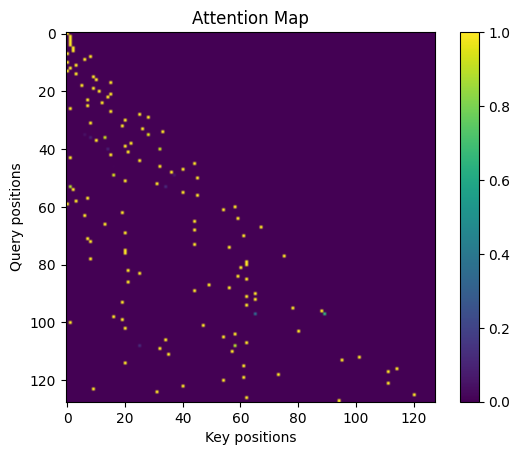

In [133]:
from torch.nn import functional as F
import matplotlib.pyplot as plt

attention = F.softmax(QKt_scaled_masked, dim=-1)

plt.imshow(attention[0].detach().cpu(), cmap='viridis')
plt.colorbar()
plt.title("Attention Map")
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.show()

Now that the attention mask is computed we can use it to scale the V tensor. The result of this operation will be the meaning of each pair of words scaled by how much they are relevant to each other in this sentence.

In [134]:
output = attention @ V
output.shape

torch.Size([1, 128, 64])

Let's wrap all that we've done in an attention head class:

In [135]:
class AttentionHead(nn.Module):
    def __init__(
        self, 
        head_size,
        block_size=CONFIG["block_size"], 
        n_embd=CONFIG["n_embd"], 
    ):
        nn.Module.__init__(self)
        
        # If head_size is not provided, use the embedding size 
        # (assume single head in transformer block)
        if head_size is None: head_size = n_embd
        self.head_size = head_size

        # Create the weight matrices for the query, key and value
        self.W_q = nn.Linear(n_embd, head_size, bias=True)
        self.W_k = nn.Linear(n_embd, head_size, bias=True)
        self.W_v = nn.Linear(n_embd, head_size, bias=True)

        # Create the causal mask and register as a buffer so it's not a parameter (not trainable)
        self.register_buffer("mask", ~torch.tril(torch.ones(block_size, block_size)).bool())

        # Create a buffer to store the scale factor for the attention scores
        self.register_buffer("scale", torch.sqrt(torch.tensor(head_size)))
        
    def forward(self, x):
        B, T, C = x.shape
        
        # Project the input into the query, key and value spaces
        # (B, T, C) -> (B, T, head_size)
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        # Matrix multiply the query and key matrices to get the attention scores
        # (how close each query is to each key)
        # (B, T, head_size) @ (B, head_size, T) -> (B, T, T)
        Kt = K.transpose(-2, -1)
        QKt = Q @ Kt

        # Scale the attention scores by the square root of the head size
        # (keep attention scores from exploding otherwise softmax will 
        # saturate and create one hot vectors)
        # (B, T, T) / sqrt(head_size) -> (B, T, T)
        QKt_scaled = QKt / self.scale

        # Mask the future tokens so that each token can only attend to previous tokens
        # (B, T, T) -> (B, T, T)
        mask = self.mask[:T, :T].to(x.device)
        QKt_masked = QKt_scaled.masked_fill(mask, float("-inf"))

        # Create the attention weights by applying a softmax to the masked attention scores
        # (B, T, T) -> (B, T, T)
        attention = F.softmax(QKt_masked, dim=-1)

        # Map the attention weights to the value space
        # in order to create an output with the same shape as the input (batch, time, channels)
        # but now with the actual meaning of each word (eg: "the" can now have an embedding of "cat" when input is "the cat jumped")
        # (B, T, T) @ (B, T, head_size) -> (B, T, head_size)
        out = attention @ V

        # Return the output
        return out

# Run a batch through the attention head
with torch.no_grad():
    x, y = sample_batch(1)
    x = token_embedding_table(x)
    out = AttentionHead(CONFIG["n_embd"] // 2)(x)
out.shape, out

(torch.Size([1, 128, 32]),
 tensor([[[ 1.0963, -0.0548,  1.1798,  ..., -0.2900, -0.4827,  0.2024],
          [ 1.0963, -0.0548,  1.1798,  ..., -0.2900, -0.4827,  0.2024],
          [ 0.5295,  0.5711,  0.4954,  ...,  0.4404,  0.3724,  0.2152],
          ...,
          [ 0.1469,  0.0161, -0.1499,  ...,  0.1638,  0.1837, -0.3101],
          [ 0.1931,  0.1153, -0.0785,  ...,  0.1290,  0.1229, -0.3158],
          [ 0.1582, -0.0083, -0.1402,  ...,  0.1295,  0.1432, -0.3165]]]))

Create a class that bundles N attention heads into a single construct that forwards the input through all heads and concatenates the outputs back
into a single tensor of the same shape as the input.

In [136]:
class MultiHeadAttention(nn.Module):
    def __init__(self, 
        n_heads=CONFIG["n_head"], 
        n_embd=CONFIG["n_embd"],
    ):
        nn.Module.__init__(self)
        
        # Create the N attention heads
        head_size = n_embd // n_heads
        self.heads = nn.ModuleList([AttentionHead(head_size) for _ in range(n_heads)])

        # Create the weight matrix that will project the concatenated 
        # outputs back into the same shape to allow the model to learn 
        # to mix the outputs of each head (otherwise each head could only 
        # influence a section of the resulting embedding)
        self.W_o = nn.Linear(n_embd, n_embd, bias=True)

    def forward(self, x):
        # Run the input through all heads and collect the outputs
        outs = []
        for head in self.heads: # TODO: vectorize this?
            out = head(x)
            outs.append(out)

        # Concatenate the outputs of all heads back into the original shape
        # [(B, T, head_size) for _ in range(n_heads)] -> (B, T, n_heads * head_size)
        mha_out = torch.concat(outs, dim=-1)

        # Project the concatenated outputs back into the same shape as the input
        # (this allows the model to learn to mix the outputs of each head)
        mha_out = self.W_o(mha_out)
        return mha_out

# Run a batch through the multi-head attention
with torch.no_grad():
    x, _ = sample_batch(1)
    x = token_embedding_table(x)
    out = MultiHeadAttention(n_heads=2)(x)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[ 0.9446, -0.0480,  0.0067,  ..., -0.2007, -0.1529,  0.2304],
          [ 0.5126,  0.3978, -0.1279,  ..., -0.0789, -0.3353, -0.0972],
          [ 0.6207,  0.1944, -0.1023,  ..., -0.1034, -0.1354,  0.0647],
          ...,
          [ 0.0065,  0.2440, -0.1198,  ...,  0.0173, -0.4093, -0.0108],
          [ 0.0377,  0.1172, -0.1222,  ..., -0.0248, -0.3602,  0.0249],
          [ 0.0836,  0.0838, -0.0875,  ...,  0.0284, -0.3744,  0.0647]]]))

Now let's create a faster attention implementation that does the same work with less tensor operations, while encapsulating the attention function in a such a way that we can hot-swap between our manual implementation and other implementations (eg: PyTorch's `F.scaled_dot_product_attention`, FlashAttention, etc).

In [137]:
def manual_scaled_dot_product_attention(
    Q: torch.Tensor,
    K: torch.Tensor, 
    V: torch.Tensor,
    attn_mask: torch.Tensor = None,
    is_causal: bool = False,
    dropout_p: float = 0.0,
    scale: float = None,
) -> torch.Tensor:
    B, n_heads, T, head_size = Q.shape
    
    # Compute scale factor (default: 1/sqrt(head_size))
    if scale is None:
        scale = 1.0 / (head_size ** 0.5)
    
    # Matrix multiply the query and key matrices to get the attention scores
    # (B, n_heads, T, head_size) @ (B, n_heads, head_size, T) -> (B, n_heads, T, T)
    Kt = K.transpose(-2, -1)
    QKt = Q @ Kt
    
    # Scale the attention scores
    QKt_scaled = QKt * scale

    # Apply attention mask if provided (before causal mask)
    if attn_mask is not None:
        if attn_mask.dtype == torch.bool: QKt_scaled = QKt_scaled.masked_fill(~attn_mask, float("-inf"))
        else: QKt_scaled = QKt_scaled + attn_mask

    # Apply causal mask if requested
    if is_causal:
        # Create causal mask: True where we should mask (upper triangle)
        mask = torch.triu(torch.ones(T, T, device=Q.device, dtype=torch.bool), diagonal=1)
        QKt_scaled = QKt_scaled.masked_fill(mask, float("-inf"))
    
    # Apply softmax to get attention weights
    # (B, n_heads, T, T) -> (B, n_heads, T, T)
    attention = F.softmax(QKt_scaled, dim=-1)
    
    # Apply dropout to attention weights (only during training)
    if dropout_p > 0.0:
        attention = F.dropout(attention, p=dropout_p)
    
    # Matrix multiply attention weights with values
    # (B, n_heads, T, T) @ (B, n_heads, T, head_size) -> (B, n_heads, T, head_size)
    output = attention @ V
    
    return output

And now let's use this attention function in our fast multi-head attention implementation where reduce tensor ops by packing Q, K, V into a single tensor and then packing all heads into a single tensor as well.

In [138]:
class FastMultiHeadAttention(nn.Module):
    def __init__(
        self, 
        n_heads,
        n_embd=CONFIG["n_embd"],
        dropout=0.0,
    ):
        nn.Module.__init__(self)

        head_size = n_embd // n_heads
        self.n_heads = n_heads
        self.head_size = head_size
        self.attn_dropout = dropout
        
        # Create single tensor with all weights for Q, K, V
        self.W_qkv = nn.Linear(n_embd, n_embd * 3, bias=True)
        
        # Create the weight matrix that will project the concatenated 
        # outputs back into the same shape to allow the model to learn 
        # to mix the outputs of each head (otherwise each head could only 
        # influence a section of the resulting embedding)
        self.W_o = nn.Linear(n_embd, n_embd, bias=True)

        # Residual dropout (applied after output projection)
        self.resid_dropout = nn.Dropout(dropout)

        # Select the attention function to use
        attention_fn_id = CONFIG["attention_fn"]
        self.attention_fn = {
            "manual": manual_scaled_dot_product_attention,
            "pytorch" : F.scaled_dot_product_attention,
        }[attention_fn_id]

    def forward(self, x):
        B, T, C = x.shape

        # Project the input into the query, key and value spaces
        # (B, T, C) -> (B, T, 3 * n_embd)
        QKV = self.W_qkv(x)

        # Split the concatenated Q, K, V into separate tensors
        # (B, T, 3 * n_embd) -> [(B, T, n_embd) for _ in range(3)]
        Q, K, V = torch.chunk(QKV, 3, dim=-1)

        # Reshape the tensors to split the embedding dimension into multiple heads
        # (B, T, n_embd) -> (B, T, n_heads, head_size)
        Q = Q.view(B, T, self.n_heads, self.head_size)
        K = K.view(B, T, self.n_heads, self.head_size)
        V = V.view(B, T, self.n_heads, self.head_size)

        # Transpose the tensors so that the head dimension is first 
        # (B, T, n_heads, head_size) -> (B, n_heads, T, head_size)
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)

        # Apply scaled dot-product attention (can hot-swap between manual and PyTorch implementations)
        # (B, n_heads, T, head_size) -> (B, n_heads, T, head_size)
        V_scaled = self.attention_fn(
            Q, K, V,
            is_causal=True,
            dropout_p=self.attn_dropout if self.training else 0.0,
        )

        # Transpose the output so that the head dimension is last
        # (B, n_heads, T, head_size) -> (B, T, n_heads, head_size)
        V_scaled_t = V_scaled.transpose(1, 2)

        # Reshape the output to concatenate the heads back into the original shape
        # (B, T, n_heads, head_size) -> (B, T, n_embd)
        V_scaled_t_realigned = V_scaled_t.contiguous().view(B, T, C)

        # Project the concatenated outputs back into the same shape as the input
        # (this allows the model to learn to mix the outputs of each head)
        output = self.W_o(V_scaled_t_realigned)

        # Apply residual dropout
        output = self.resid_dropout(output)

        # Return the multi-head attention output
        return output

# Run a batch through the fast multi-head attention
with torch.no_grad():
    x, _ = sample_batch(1)
    x = token_embedding_table(x)
    out = FastMultiHeadAttention(2)(x)
    out.shape, out

Now let's create the feedforward network that follows the attention layer in the transformer block. The FFN layer should scale the input up by 4x, apply a non-linearity and then scale it back down to the original dimensions.

In [139]:
ffn1 = nn.Linear(n_embd, n_embd * 4)
gelu = nn.GELU()
ffn2 = nn.Linear(n_embd * 4, n_embd)
n_heads = CONFIG["n_head"]
head_size = n_embd // n_heads
lm_head = nn.Linear(n_embd, head_size)
output_head = lm_head(ffn2(gelu(ffn1(output))))
output_head.shape, output_head

(torch.Size([1, 128, 32]),
 tensor([[[-0.5546,  1.6853, -0.4485,  ...,  1.7630,  0.6957, -1.7066],
          [ 0.8937,  3.4405,  1.1745,  ...,  1.2521, -1.5569, -2.4270],
          [ 0.8937,  3.4405,  1.1745,  ...,  1.2521, -1.5569, -2.4270],
          ...,
          [ 0.3836,  3.4361,  0.1493,  ...,  2.8562,  1.9644, -0.1932],
          [-0.9130,  2.4948, -0.0887,  ...,  1.9636, -0.3717, -1.4399],
          [-1.3344,  0.6769,  1.3615,  ..., -2.3570, -0.4150,  0.5209]]],
        grad_fn=<ViewBackward0>))

Wrap the FFN in a class:

In [140]:
class FeedForward(nn.Module):
    def __init__(self, n_embd=CONFIG["n_embd"], dropout=0.0):
        nn.Module.__init__(self)
        
        self.ffn1 = nn.Linear(n_embd, n_embd * 4, bias=True)

        # We use the approximate tanh GELU as this is faster to compute and has similar properties to the exact GELU
        # NOTE: we also do this to match the HuggingFace implementation so that we can load their checkpoints
        self.gelu = nn.GELU(approximate='tanh')
        
        self.ffn2 = nn.Linear(n_embd * 4, n_embd, bias=True)
        
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.ffn1(x)
        x = self.gelu(x)
        x = self.ffn2(x)
        x = self.dropout(x)
        return x

# Run a batch through the feedforward network
with torch.no_grad():
    x,y = sample_batch(1)
    x = token_embedding_table(x)
    mha_out = MultiHeadAttention()(x)
    out = FeedForward()(mha_out)
    out.shape, out

Now that we have all the components of a transformer block, let's wrap them in a class:

In [141]:
class TransformerBlock(nn.Module):
    def __init__(
        self, 
        n_embd=CONFIG["n_embd"], 
        n_heads=CONFIG["n_head"], 
        dropout=CONFIG["dropout"],
        layer_norm_enabled=CONFIG["layer_norm_enabled"]
    ):
        nn.Module.__init__(self)
        self.head = FastMultiHeadAttention(n_heads, n_embd=n_embd, dropout=dropout)
        self.ffn = FeedForward(n_embd, dropout=dropout)
        self.ln1 = nn.LayerNorm(n_embd, bias=True) if layer_norm_enabled else nn.Identity()
        self.ln2 = nn.LayerNorm(n_embd, bias=True) if layer_norm_enabled else nn.Identity()

    def forward(self, x):
        # Normalize the input features, run them through the 
        # attention layer and then add the input (residual connection)
        x = x + self.head(self.ln1(x))

        # Normalize the input features, run them through the 
        # feedforward network and then add the input (residual connection)
        x = x + self.ffn(self.ln2(x))

        # Return the transformed features
        return x

# Run a batch through the transformer block
with torch.no_grad():
    x, y = sample_batch(1)
    x = token_embedding_table(x)
    out = TransformerBlock()(x)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[ 1.0390, -0.3038, -1.9539,  ...,  3.0065,  1.1245,  1.3414],
          [-0.3512,  0.0107, -2.6772,  ...,  0.9827,  0.9745,  0.5914],
          [ 0.1563, -2.9456, -1.0875,  ...,  0.9997, -1.8928, -0.1749],
          ...,
          [ 0.9981, -0.4290, -1.1704,  ...,  2.7440,  0.4851,  1.3101],
          [ 0.6388,  0.1483, -0.2182,  ...,  0.7152,  0.0808, -0.9803],
          [ 0.2410, -2.8050, -0.8565,  ...,  0.7066, -2.1119, -0.2062]]]))

Now that we have the transformer block, let's create the entire transformer model (decoder only):

In [142]:
class Transformer(nn.Module):
    def __init__(
        self,
        vocab_size=TOKENIZER.get_vocab_size(),
        n_embd=CONFIG["n_embd"], 
        n_layer=CONFIG["n_layer"],
        n_head=CONFIG["n_head"],
        block_size=CONFIG["block_size"],
        dropout=CONFIG["dropout"]
    ):
        nn.Module.__init__(self)

        # Create the token embedding table (maps tokens to learnable embeddings)
        # (B, T) -> (B, T, C)
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)

        # Create the position embedding table (maps positions to learnable embeddings)
        # (T,) -> (T, C)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)

        # Embedding dropout (applied after combining token + position embeddings)
        self.emb_dropout = nn.Dropout(dropout)

        # Create the transformer blocks (pass n_embd and n_head explicitly)
        self.blocks = nn.ModuleList([
            TransformerBlock(n_embd=n_embd, n_heads=n_head, dropout=dropout) 
            for _ in range(n_layer)
        ])

        # Create the language model head (maps the final layer to the vocabulary size) 
        # (B, T, C) -> (B, T, vocab_size)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        
        # Weight tying: share weights between token embedding and lm_head.
        # The embedding maps token IDs → vectors; the lm_head maps vectors → token logits.
        # Both use the same semantic space, so sharing weights reduces parameters (~38M for GPT-2)
        # and acts as regularization. See: "Using the Output Embedding to Improve Language Models"
        # (Press & Wolf, 2016) https://arxiv.org/abs/1608.05859
        # NOTE: we also do this to be compatible with the HuggingFace implementation so that we can load their checkpoints
        self.lm_head.weight = self.token_embedding_table.weight

        # Create the final layer normalization (normalizes the output of the last transformer block)
        # (B, T, C) -> (B, T, C)
        self.ln_final = nn.LayerNorm(n_embd, bias=True) if CONFIG["layer_norm_enabled"] else nn.Identity()

    def forward(self, x):
        B, T = x.shape

        # Create token embeddings
        # (B, T) -> (B, T, C)
        tok_emb = self.token_embedding_table(x)

        # Create position embeddings and unsqueeze 
        # them to align with the token embeddings
        # (T,) -> (T, C) -> (1, T, C)
        pos = torch.arange(T, device=x.device)
        pos_emb = self.position_embedding_table(pos)
        pos_emb = pos_emb.unsqueeze(0)

        # Add the token embeddings and 
        # position embeddings to create the input
        x = tok_emb + pos_emb

        # Apply embedding dropout
        x = self.emb_dropout(x)

        # Run the input through all transformer blocks
        # (use gradient checkpointing to save memory if enabled)
        if CONFIG["gradient_checkpointing"]:    
            from torch.utils.checkpoint import checkpoint_sequential
            x = checkpoint_sequential(self.blocks, segments=len(self.blocks), input=x)
        else:
            for block in self.blocks: x = block(x)

        # Project the output to the vocabulary size
        # Normalize the output of the last transformer block and feed it through the language model head
        # to project to the vocabulary size
        # (B, T, C) -> (B, T, vocab_size)
        x = self.lm_head(self.ln_final(x))

        # Return the projected output
        return x

# Run a batch through the transformer
with torch.no_grad():
    x, y = sample_batch(1)
    out = Transformer()(x)
out.shape, out[0][0]

(torch.Size([1, 128, 109]),
 tensor([ -9.1252,   1.0796,   4.4396,   4.0474,   7.5955,   8.6876,   7.9043,
          -5.9459,  -0.0487,   1.3350,  -6.1032,  -6.8855, -17.8814,  -7.9458,
          10.6321,  -2.9545,   0.1967,  -1.8007,  -0.4479,  -6.6680,  -3.0490,
           7.7386,  -2.2893,  10.4198,   1.8089,  -9.5194,   3.2857,  -7.3313,
          -7.8021,   9.6791,  -9.0023, -16.9322,   2.3371,   2.2981,   0.6888,
          12.8985,   6.5384,  -1.5840,  -1.9972,  -5.7154,  -2.5496,  -3.7295,
          -6.4338,  -1.8726,  10.0399,  11.7371,  -1.9157,  -1.0704,  -2.9076,
           1.5876,  -0.4314, -10.5178,  -1.7398,  28.2128,   4.1178,  13.6388,
          13.0584,  -0.1058,  -4.8511,  -4.2708, -13.3565,   0.6549,  -1.9024,
         -10.0854, -21.0648,   6.7163,   0.6915,  33.9618,  -8.3200,  -2.5318,
         -11.1543,  -2.0454,   4.3991,   2.0616,   1.3948, -18.4532,   4.3742,
          15.1693,  -3.9843,   9.7812,  15.6466,   0.2307,  -5.3177,   1.5632,
          -2.5129,  -5.4

Create the training dataset, which returns a different sequence of length `block_size` for each index in the dataset:

In [143]:
# After tokenizing DATASET_TOKENS
val_ratio = 0.1
val_indices = set(range(0, len(DATASET_TOKENS) - CONFIG["block_size"], int(1/val_ratio)))
train_indices = [i for i in range(len(DATASET_TOKENS) - CONFIG["block_size"]) if i not in val_indices]
val_indices = list(val_indices)

print(f"Train samples: {len(train_indices):,}, Val samples: {len(val_indices):,}")

Train samples: 2,971,461, Val samples: 330,163


In [182]:
from torch.utils.data import Dataset

class SlidingWindowDataset(Dataset):
    def __init__(
        self, 
        tokens, 
        block_size=CONFIG["block_size"]
    ):  
        # Ensure tokens are a tensor at creation so that 
        # splitting the dataset into batches is efficient
        self.tokens = torch.tensor(tokens)
        self.block_size = block_size

    def __getitem__(self, idx):
        x = self.tokens[idx:idx+self.block_size]
        y = self.tokens[idx+1:idx+self.block_size+1]
        return x, y

    def __len__(self):
        return len(self.tokens) - self.block_size


# Print N items from the dataset
dataset = SlidingWindowDataset(DATASET_TOKENS)
print("Dataset length:", len(dataset))
for i in range(100, 110):
    x, y = dataset[i]
    print(f"--- {i} ---")
    print("x:" + TOKENIZER.decode(x.tolist()))
    print("y:" + TOKENIZER.decode(y.tolist()))

Dataset length: 3301624
--- 100 ---
x:example, the text on pages 32 and 62 now corresponds exactly with the runes on Thror's Map. More important is the matter of Chap
y:xample, the text on pages 32 and 62 now corresponds exactly with the runes on Thror's Map. More important is the matter of Chapt
--- 101 ---
x:xample, the text on pages 32 and 62 now corresponds exactly with the runes on Thror's Map. More important is the matter of Chapt
y:ample, the text on pages 32 and 62 now corresponds exactly with the runes on Thror's Map. More important is the matter of Chapte
--- 102 ---
x:ample, the text on pages 32 and 62 now corresponds exactly with the runes on Thror's Map. More important is the matter of Chapte
y:mple, the text on pages 32 and 62 now corresponds exactly with the runes on Thror's Map. More important is the matter of Chapter
--- 103 ---
x:mple, the text on pages 32 and 62 now corresponds exactly with the runes on Thror's Map. More important is the matter of Chapter
y:ple, the 

There is an issue with this sliding dataset strategy though. If we wanted to create a validation dataset by sampling different indices most of the selected sequences will overlap the training sequences. Therefore it would be better to create a dataset based on non-overlapping sequences so that the indexes target those sequences instead of the sequence offsets.

In [183]:
from torch.utils.data import Dataset

class ChunkedDataset(Dataset):
    def __init__(
        self, 
        tokens, 
        block_size=CONFIG["block_size"],
        indices=None
    ):
        self.block_size = block_size

        # Split into non-overlapping chunks of (block_size + 1)
        # +1 because we need x and y to be offset by 1
        chunk_size = block_size + 1
        n_chunks = len(tokens) // chunk_size

        # Truncate tokens to fit exactly n_chunks
        tokens = tokens[:n_chunks * chunk_size]

        # Reshape into chunks: (n_chunks, chunk_size)
        self.chunks = torch.tensor(tokens).view(n_chunks, chunk_size)
        self.indices = range(len(self.chunks)) if indices is None else indices

    def __getitem__(self, idx):
        index = self.indices[idx]
        chunk = self.chunks[index]
        x = chunk[:-1]  # First block_size tokens
        y = chunk[1:]   # Last block_size tokens (shifted by 1)
        return x, y

    def __len__(self):
        return len(self.indices)

# Print N items from the dataset
dataset = ChunkedDataset(DATASET_TOKENS)
print("Dataset length:", len(dataset))
for i in range(100, 110):
    x, y = dataset[i]
    print(f"--- {i} ---")
    print("x:" + TOKENIZER.decode(x.tolist()))
    print("y:" + TOKENIZER.decode(y.tolist()))

Dataset length: 25594
--- 100 ---
x:hooded cloak on the nearest peg, and "Dwalin at your service!" he said with a low bow.

"Bilbo Baggins at yours!" said the hobbi
y:ooded cloak on the nearest peg, and "Dwalin at your service!" he said with a low bow.

"Bilbo Baggins at yours!" said the hobbit
--- 101 ---
x:, too surprised to ask any questions for the moment. When the silence that followed had become uncomfortable, he added: "I am ju
y: too surprised to ask any questions for the moment. When the silence that followed had become uncomfortable, he added: "I am jus
--- 102 ---
x:t about to take tea; pray come and have some with me." A little stiff perhaps, but he meant it kindly. And what would you do, if
y: about to take tea; pray come and have some with me." A little stiff perhaps, but he meant it kindly. And what would you do, if 
--- 103 ---
x:an uninvited dwarf came and hung his things up in your hall without a word of explanation?

They had not been at table long, in 
y:n uninvited

Now that we have a chunked dataset, we can create a train and validation dataset by sampling different indices:

In [146]:
import random

val_ratio = 0.1 # TODO: move to config
train_dataset_indices = random.sample(range(len(dataset)), int(len(dataset) * (1 - val_ratio)))
val_dataset_indices = [i for i in range(len(dataset)) if i not in train_dataset_indices]

train_dataset = ChunkedDataset(DATASET_TOKENS, indices=train_dataset_indices)
val_dataset = ChunkedDataset(DATASET_TOKENS, indices=val_dataset_indices)

train_dataset_length = len(train_dataset)
val_dataset_length = len(val_dataset)
total_dataset_length = train_dataset_length + val_dataset_length

print("Train dataset length:", len(train_dataset))
print("Val dataset length:", len(val_dataset))
print(f"Train + val dataset length: {total_dataset_length}")
print(f"Original dataset length: {len(dataset)}")
print(f"Val ratio: {val_dataset_length / total_dataset_length:.2f}")

Train dataset length: 23034
Val dataset length: 2560
Train + val dataset length: 25594
Original dataset length: 25594
Val ratio: 0.10


Create train data loader that iterates the dataset in random batches instead of sequential items:

In [ ]:
def create_dataloader(
    dataset, 
    shuffle=True, 
    batch_size=CONFIG["batch_size"], 
    num_workers=CONFIG["num_workers"], 
    pin_memory=CONFIG["pin_memory"]
):
    from torch.utils.data import DataLoader
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        # TODO: this is probably not required after chunking
        drop_last=True  # Ensures consistent batch sizes
        # TODO: try this
        # TODO: if pinned_memory?
        #prefetch_factor=4 if CONFIG["num_workers"] > 0 else None,
        #persistent_workers=CONFIG["num_workers"] > 0,
    )
    return loader

# TODO: show \n inline
train_loader = create_dataloader(train_dataset)
val_loader = create_dataloader(val_dataset)
for x, y in train_loader:
    for i in range(10):
        print("# X #:" + TOKENIZER.decode(x[i].tolist()))
        print("# Y #:" + TOKENIZER.decode(y[i].tolist()))
        print("---")
    break
for x, y in val_loader:
    for i in range(10):
        print("# X #:" + TOKENIZER.decode(x[i].tolist()))
        print("# Y #:" + TOKENIZER.decode(y[i].tolist()))
        print("---")
    break

# X #:That is good!" said Bergil. "We boys are no longer allowed to pass the Gate without an elder. Now we shall see better."

Beyond 
# Y #:hat is good!" said Bergil. "We boys are no longer allowed to pass the Gate without an elder. Now we shall see better."

Beyond t
---
# X #:behind; then dancing among the trees he began to sing a song to infuriate them and bring them all after him, and also to let the
# Y #:ehind; then dancing among the trees he began to sing a song to infuriate them and bring them all after him, and also to let the 
---
# X #:eech' of the West-lands of Middle-earth in the Third Age. In the course of that age it had become the native language of nearly 
# Y #:ech' of the West-lands of Middle-earth in the Third Age. In the course of that age it had become the native language of nearly a
---
# X #:a tall man, taller than all the rest; from his helm as a crest a white horsetail flowed. He advanced until the point of his spea
# Y #: tall man, taller than all the rest; 

Create the transformer model:

In [148]:
model = Transformer()
#model = torch.compile(model, mode="reduce-overhead") # TODO: limited support on MPS, best on CUDA
model.to(DEVICE)
model.train()

Transformer(
  (token_embedding_table): Embedding(109, 64)
  (position_embedding_table): Embedding(128, 64)
  (emb_dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (head): FastMultiHeadAttention(
        (W_qkv): Linear(in_features=64, out_features=192, bias=True)
        (W_o): Linear(in_features=64, out_features=64, bias=True)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): FeedForward(
        (ffn1): Linear(in_features=64, out_features=256, bias=True)
        (gelu): GELU(approximate='tanh')
        (ffn2): Linear(in_features=256, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (lm_head): Linear(in_features=64, out_features=109, bias=False)
  (ln_final): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
)

If `tune_batch_size` is true, find the optimal batch size and gradient accumulation steps for the model:

In [149]:
# TODO: this must be done before dataloader creation
if CONFIG["tune_batch_size"]:
    from aiml_notebooks import find_optimal_batch_config
    vocab_size = TOKENIZER.get_vocab_size()
    result = find_optimal_batch_config(
        model=model,
        vocab_size=vocab_size,
        block_size=CONFIG["block_size"],
    )
    recommended = result['recommended']
    if CONFIG["batch_size"] == "auto": CONFIG["batch_size"] = recommended['batch_size']
    if CONFIG["gradient_accumulation_steps"] == "auto": CONFIG["gradient_accumulation_steps"] = recommended['gradient_accumulation_steps']

In [150]:
from tqdm import tqdm

@torch.no_grad()
def evaluate(model, loader):
    # Ensure model is in evaluation mode
    # (eg: disable dropout)
    model.eval()
    
    # We want to calculate the average loss over all the batches
    
    # Run through all the dataset batches,
    # compute the loss for each batch and accumulate the total loss
    total_loss = 0.0
    batch_bar = tqdm(loader, desc="Evaluating", leave=False)
    for x, y in batch_bar:
        # Load batch to device
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        # Forward pass and calculate loss
        with autocast():
            logits = model(x)
            logits = logits.permute(0, 2, 1)
            loss = F.cross_entropy(logits, y)
        
        # Accumulate the loss
        total_loss += loss.item()
    
    # Average the loss over all the batches and return that as the dataset loss
    loss = total_loss / len(loader)
    return loss

# Evaluate the model on the validation set
val_loss = evaluate(model, val_loader)
print(f"Val loss: {val_loss:.4f}")

Val loss: 41.1594


Create the training loop and train for `n_epochs`:

In [151]:
from aiml_notebooks import get_grad_norm

def train(
    model, 
    train_loader,
    val_loader,
    n_epochs=CONFIG['n_epochs'], 
    lr=CONFIG["learning_rate"], 
    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
    # TODO: results map
    train_losses=None,
    val_losses=None,
    grad_norms=None
):
    # Create the optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    # Initialize lists to store losses and gradient norms
    train_losses = [] if train_losses is None else train_losses
    val_losses = [] if val_losses is None else val_losses
    grad_norms = [] if grad_norms is None else grad_norms

    # Train for `n_epochs`
    postfix_map = {}
    for epoch in range(n_epochs):
        # Set the model to training mode (sanity: we may have set it to evaluation mode at some point last epoch)
        model.train()

        # Zero the gradients
        optimizer.zero_grad()

        # Iterate over the training data loader
        batch_losses = []
        batch_grad_norms = []
        batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}")
        for batch_idx, (x, y) in enumerate(batch_bar):
            # Move the batch to the device
            x, y = x.to(DEVICE), y.to(DEVICE)

            with autocast():
                # Forward pass
                logits = model(x)

                # Permute the logits to match the shape of the targets
                # (B, T, C) -> (B, C, T)
                logits = logits.permute(0, 2, 1) # TODO: review this

                # Compute the loss
                loss = F.cross_entropy(logits, y)
            
            # Accumulate the loss
            batch_loss = loss.item()
            batch_losses.append(batch_loss)
            postfix_map["train_loss"] = f"{batch_loss:.4f}"

            # Backward pass
            # (each batch is scaled by gradient_accumulation_steps to avoid gradient explosion)
            SCALER.scale(loss / gradient_accumulation_steps).backward()

            # In case this is an optimization step, then adjust the model 
            # parameters based on the gradients accumulated so far
            is_optimization_step = ((batch_idx + 1) % gradient_accumulation_steps == 0) or (batch_idx + 1 == len(train_loader))
            if is_optimization_step:
                SCALER.unscale_(optimizer)

                # Calculate the gradient norm 
                # (used to monitor training stability)
                grad_norm = get_grad_norm(model)
                batch_grad_norms.append(grad_norm)
                postfix_map["grad_norm"] = f"{grad_norm:.4f}"
                
                # Update the model parameters
                SCALER.step(optimizer)
                SCALER.update()

                # Zero the gradients so we can start accumulating gradients again
                optimizer.zero_grad()

            # Update the batch bar postfix at end of each batch
            batch_bar.set_postfix(**postfix_map)

        # Calculate the final epoch grad norm
        epoch_grad_norms = sum(batch_grad_norms) / len(batch_grad_norms)
        grad_norms.append(epoch_grad_norms)
        postfix_map["grad_norm"] = f"{epoch_grad_norms:.4f}"

        # Calculate the final epoch train loss
        epoch_train_loss = sum(batch_losses) / len(batch_losses)
        train_losses.append(epoch_train_loss)
        postfix_map["train_loss"] = f"{epoch_train_loss:.4f}"

        # Evaluate the model on the validation set
        epoch_val_loss = evaluate(model, val_loader)
        val_losses.append(epoch_val_loss)
        postfix_map["val_loss"] = f"{epoch_val_loss:.4f}"

        # Update the batch bar with the final results
        batch_bar.set_postfix(**postfix_map)

    # Return the training results
    return dict(
        train_losses=train_losses,
        val_losses=val_losses,
        grad_norms=grad_norms   
    )

# Train the model for `n_epochs`
train_losses, val_losses, grad_norms = [], [], []

n_epochs = CONFIG['n_epochs']
result = train(
    model, 
    train_loader,
    val_loader,
    n_epochs=n_epochs,
    train_losses=train_losses,
    val_losses=val_losses,
    grad_norms=grad_norms
)
train_losses = result['train_losses']
val_losses = result['val_losses']
grad_norms = result['grad_norms']

Epoch 100/100: 100%|██████████| 359/359 [00:09<00:00, 36.91it/s, grad_norm=0.1678, train_loss=1.7333, val_loss=1.5503]


Plot training losses and gradient norms:

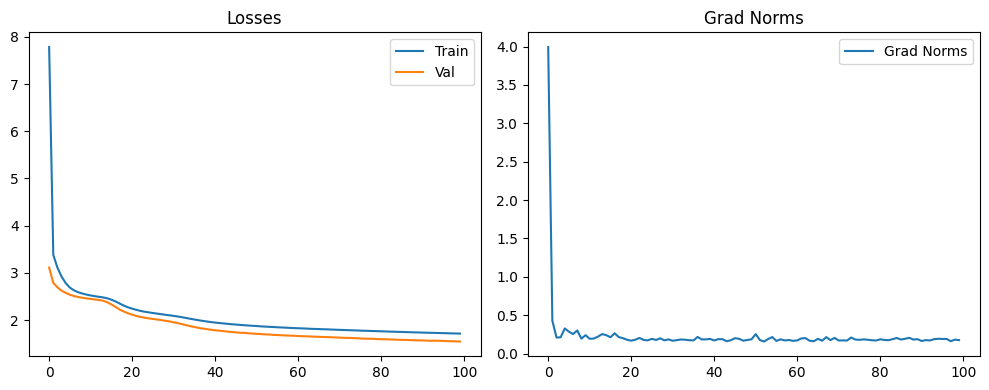

In [186]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4)) 
axes[0].plot(train_losses, label="Train")
axes[0].plot(val_losses, label="Val")
axes[0].set_title("Losses")
axes[0].legend()
axes[1].plot(grad_norms, label="Grad Norms")
axes[1].set_title("Grad Norms")
axes[1].legend()
plt.tight_layout()
plt.show()

Test generation with the trained model:

In [187]:
import time

@torch.no_grad()
def generate(
    model, 
    prompt, 
    max_len=1000, 
    block_size=CONFIG["block_size"], 
    tokenizer=TOKENIZER
):  
    # Start timing the generation
    start = time.time()

    # Set the model in evaluation mode
    # (eg: ensures dropout is disabled)
    model.eval()
    
    # Encode the prompt into token ids
    tokens = tokenizer.encode(prompt)

    # Turn tokens into tensor
    tokens_t = torch.tensor(tokens)

    # Move the tensor to the model's device
    device = next(model.parameters()).device
    tokens_t = tokens_t.to(device)

    # Add a batch dimension to the tensor to 
    # match the model's input shape
    # (T, C) -> (B, T, C)
    tokens_t = tokens_t.unsqueeze(0)

    # Print the prompt without a newline 
    # (we'll print each token as it's generated)
    print(prompt, end="", flush=True)

    # Sample next tokens one by one
    generated_tokens_s = []
    fw_token_times = []
    while len(generated_tokens_s) < max_len:
        # Forward pass to get the logits for each timestep
        # (B, T, C) -> (B, T, vocab_size)
        _start = time.time()
        logits = model(tokens_t)
        _end = time.time()
        _elapsed = _end - _start
        fw_token_times.append(_elapsed)

        # Retrieve only the logits for the last timestep
        # since we only want to sample the token after the last one
        # (preserve batch and vocab dimensions but lock in the last timestep)
        # (B, T, vocab_size) -> (B, vocab_size)
        logits = logits[:, -1, :]

        # Use softmax to convert logits to a 
        # probability distribution to sample from
        # (B, vocab_size) -> (B, vocab_size)
        probs = F.softmax(logits, dim=-1)

        # Sample one vocab index from the distribution
        # (B, vocab_size) -> (B, 1)
        next_token_idx = torch.multinomial(probs, num_samples=1)

        # Convert the sampled index to a scalar
        # (B, 1) -> ()
        next_token_idx = next_token_idx.squeeze().item()

        # Append the token to the context window
        tokens.append(next_token_idx)

        # Truncate the context window to the last `block_size` tokens
        # (model's context limit is `block_size` tokens)
        tokens = tokens[-block_size:]

        # Turn tokens into tensor
        tokens_t = torch.tensor(tokens)

        # Move the tensor to the model's device
        tokens_t = tokens_t.to(device)

        # Add a batch dimension to the tensor to 
        # match the model's input shape
        # (T, C) -> (B, T, C)
        tokens_t = tokens_t.unsqueeze(0)

        # Decode the token and print it (stream the output)
        next_token_s = tokenizer.decode([next_token_idx])
        print(next_token_s, end="", flush=True)
        generated_tokens_s.append(next_token_s)
   
    # Count the number of tokens generated
    num_tokens = len(generated_tokens_s)
    
    # Join the generated tokens into a string
    generated_text = "".join(generated_tokens_s)

    # Measure the time it took to generate the text
    end = time.time()
    elapsed = end - start

    # Return the result
    return dict(    
        text=generated_text,
        num_tokens=num_tokens,
        elapsed=elapsed,
        fw_token_times=fw_token_times,
    )

# Generate text with the trained model
prompt = "Frodo picked up the sword"
result = generate(model, prompt)
num_tokens = result['num_tokens']
elapsed = result['elapsed']
tokens_per_second = num_tokens / elapsed
print(f"\n\nGenerated {num_tokens} tokens in {elapsed:.2f} seconds ({tokens_per_second:.2f} tokens/second)")

Frodo picked up the sword beliems were you may for water meet on him as not to with and shouth he darkness, and in and voes they greach heed fales. That Made is for may pight depale, if its if strong up to the lade the smalls."

Frodo. Even the could be have stood no became. We shem any done was neard as left mound the was a fally of the road yort of Isengthose king anumh 're not you like arches; you an on you can rasome great not dragolas. Merry for in the ento was begards the Dimpering the hollow a squess! Wizard. Farass the greaturned known or just senet in him never the New more. The middless his of the might horse smalivent day of the mely come (on the was still lake. Whis and had the the that all Seched are any Rey fill stay-compliel; she visit to Once? There again. When Aragorn crapped fire gone and up, his all call on uth her alway fade away the over shadow still thate they found west nut blacks meet that the gragon weard the the Tretch Boom, toge Food Stong they as depart answ

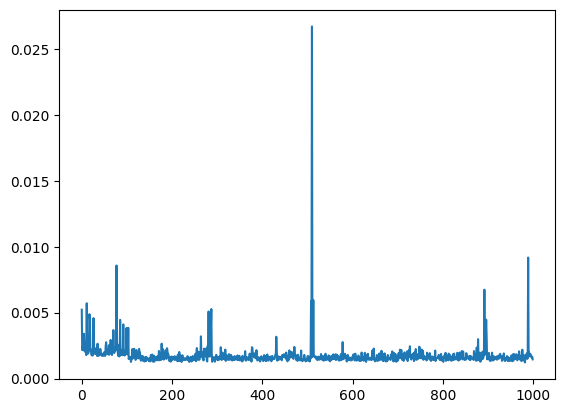

In [189]:
from matplotlib import pyplot
pyplot.plot(result['fw_token_times'])
pyplot.show()

In [154]:
@torch.no_grad()
def generate_sampler(
    model,
    text,
    max_len=100,
    temperature=1.0,
    top_k=None,
    top_p=None,
    min_p=None,
    repetition_penalty=1.0,
    frequency_penalty=0.0,
    presence_penalty=0.0,
    stop_tokens=None,
    block_size=CONFIG["block_size"],
    tokenizer=TOKENIZER,
):
    """Generate text with configurable sampling strategies.
    
    Args:
        model: The language model
        text: Initial prompt text
        max_len: Maximum number of tokens to generate
        temperature: Controls randomness. Higher = more random, lower = more deterministic.
                     Use 0 for greedy decoding (always pick most likely token).
        top_k: If set, only sample from the top k most likely tokens.
        top_p: (Nucleus sampling) If set, sample from smallest set of tokens 
               whose cumulative probability exceeds p. Typical values: 0.9-0.95.
        min_p: If set, filter out tokens with probability < min_p * max_probability.
               Helps remove very unlikely tokens dynamically.
        repetition_penalty: Penalty for tokens that have appeared in the context.
                           1.0 = no penalty, >1.0 = discourage repetition. Typical: 1.1-1.3.
        frequency_penalty: Penalty proportional to token frequency in generated text.
                          0.0 = no penalty, >0.0 = discourage frequent tokens. Typical: 0.0-2.0.
        presence_penalty: Flat penalty for tokens that have appeared at all.
                         0.0 = no penalty, >0.0 = encourage new topics. Typical: 0.0-2.0.
        stop_tokens: List of token IDs that stop generation when encountered.
        block_size: Maximum context length
        tokenizer: Tokenizer to use for encoding/decoding
    
    Returns:
        Generated text string
    """
    model.eval()
    device = next(model.parameters()).device
    tokens = tokenizer.encode(text)
    tokens_t = torch.tensor(tokens).to(device).unsqueeze(0)
    output_tokens = []
    generated_token_counts = {}  # Track frequency of generated tokens
    
    while len(output_tokens) < max_len:
        logits = model(tokens_t)
        logits = logits[:, -1, :].clone()  # Get logits for the last position
        
        # Apply repetition penalty to tokens in context
        if repetition_penalty != 1.0:
            for token_id in set(tokens):
                if logits[0, token_id] > 0:
                    logits[0, token_id] /= repetition_penalty
                else:
                    logits[0, token_id] *= repetition_penalty
        
        # Apply frequency penalty (proportional to count in generated text)
        if frequency_penalty != 0.0:
            for token_id, count in generated_token_counts.items():
                logits[0, token_id] -= frequency_penalty * count
        
        # Apply presence penalty (flat penalty if token appeared)
        if presence_penalty != 0.0:
            for token_id in generated_token_counts.keys():
                logits[0, token_id] -= presence_penalty
        
        # Apply temperature scaling
        if temperature == 0:
            # Greedy decoding
            idx = logits.argmax(dim=-1).item()
        else:
            if temperature != 1.0:
                logits = logits / temperature
            
            # Convert to probabilities for filtering
            probs = F.softmax(logits, dim=-1)
            
            # Apply min_p filtering (dynamic threshold based on max probability)
            if min_p is not None and min_p > 0:
                max_prob = probs.max()
                min_prob_threshold = min_p * max_prob
                probs = torch.where(probs < min_prob_threshold, torch.zeros_like(probs), probs)
            
            # Apply top_k filtering
            if top_k is not None and top_k > 0:
                top_k_values, top_k_indices = torch.topk(probs, k=min(top_k, probs.size(-1)), dim=-1)
                probs = torch.zeros_like(probs).scatter_(-1, top_k_indices, top_k_values)
            
            # Apply top_p (nucleus) filtering
            if top_p is not None and top_p < 1.0:
                sorted_probs, sorted_indices = torch.sort(probs, descending=True, dim=-1)
                cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
                
                # Find cutoff index where cumulative prob exceeds top_p
                sorted_mask = cumulative_probs - sorted_probs > top_p
                sorted_probs[sorted_mask] = 0.0
                
                # Scatter back to original positions
                probs = torch.zeros_like(probs).scatter_(-1, sorted_indices, sorted_probs)
            
            # Renormalize probabilities
            probs = probs / probs.sum(dim=-1, keepdim=True)
            
            # Handle edge case where all probs are zero
            if torch.isnan(probs).any() or probs.sum() == 0:
                probs = F.softmax(logits, dim=-1)
            
            # Sample from the distribution
            idx = torch.multinomial(probs, num_samples=1).squeeze().item()
        
        # Check for stop tokens
        if stop_tokens is not None and idx in stop_tokens:
            break
        
        # Update token counts for frequency penalty
        generated_token_counts[idx] = generated_token_counts.get(idx, 0) + 1
        
        tokens.append(idx)
        tokens = tokens[-block_size:]
        tokens_t = torch.tensor(tokens).to(device).unsqueeze(0)
        output_tokens.append(idx)
    
    text = text + tokenizer.decode(output_tokens)
    return text

# Example usage with different sampling strategies
model.eval()

print("=== Greedy (temperature=0) ===")
print(generate_sampler(model, "Frodo picked up the sword", max_len=200, temperature=0))

print("\n=== Low temperature (0.7) ===")
print(generate_sampler(model, "Frodo picked up the sword", max_len=200, temperature=0.7))

print("\n=== Top-k (k=50) ===")
print(generate_sampler(model, "Frodo picked up the sword", max_len=200, top_k=50))

print("\n=== Nucleus sampling (top_p=0.9) ===")
print(generate_sampler(model, "Frodo picked up the sword", max_len=200, top_p=0.9))

print("\n=== Combined (temp=0.8, top_p=0.95, rep_penalty=1.2) ===")
print(generate_sampler(model, "Frodo picked up the sword", max_len=200, 
                       temperature=0.8, top_p=0.95, repetition_penalty=1.2))


=== Greedy (temperature=0) ===
Frodo picked up the swords of the Elves of the Elves of the Elves of the Elves of the Elves of the Elves of the Elves of the Elves of the Elves of the Elves of the Elves of the Elves of the Elves of the Elves of the Elves of 

=== Low temperature (0.7) ===
Frodo picked up the swords of Deal of Mr. I was alive Minas that that you are not us of Gollum. The Hancome must them that it the tower. All the sat even a liven the grown the of made under, and they when at the Gond the road

=== Top-k (k=50) ===
Frodo picked up the swords or rimes.

"And fall the dazy cake were a vasts. Up all nighty," Éo then beginning first to even a wimi'_ And about as tell it, as stepped and word: "I said That not is," said Gill asked: "but I mus

=== Nucleus sampling (top_p=0.9) ===
Frodo picked up the sword. When in was had the voice sat he the hold in clooking didnes been his with a despart as the could and of creat let of the Minas Gandalf of the distar not of the deep fire mi

Check activations of each layer:


ACTIVATION STATISTICS
Layer                   Mean          Std      Max Abs
----------------------------------------------------------------------
input                 0.0079       0.8919       3.9783
block_0               0.3136       3.2440      18.5794
block_1               0.7742       5.9107      53.2501
final_ln             -0.0730       0.4283       2.9476

Activation Growth Rate (Final/Initial): 0.74x
Initial max abs: 3.9783
Final max abs: 2.9476


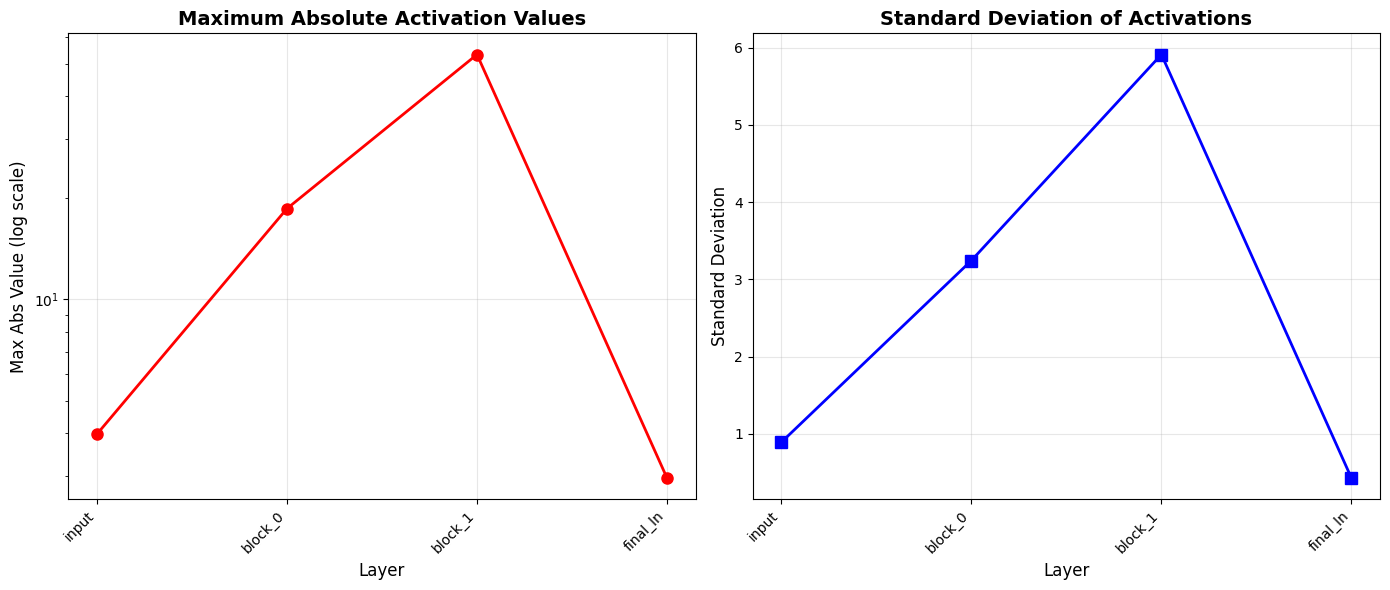

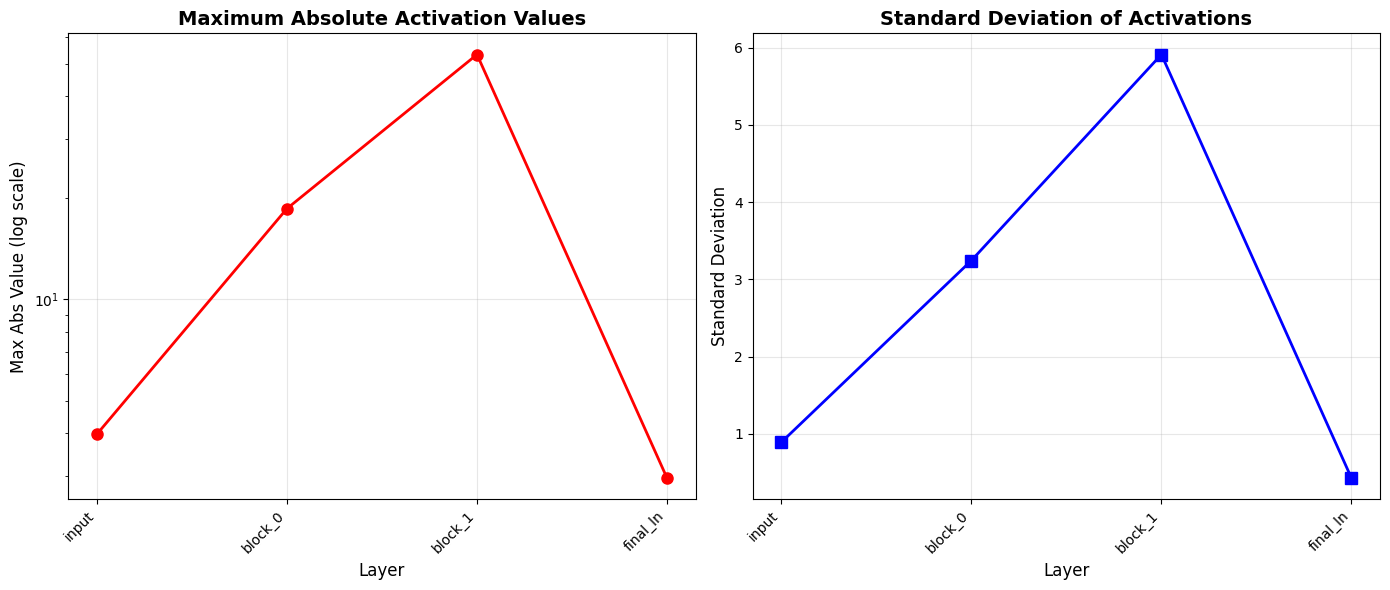

In [155]:
from aiml_notebooks import track_block_activations, plot_activation_stats

# Get a sample batch
x, y = sample_batch(1)
x = x.to(DEVICE)

# Track activations using imported utility
stats = track_block_activations(model, x, layer_norm_enabled=CONFIG["layer_norm_enabled"])

# Visualize and print summary using imported utility
plot_activation_stats(stats)

Now let's benchmark the performance against a pretrained model from HuggingFace:

In [156]:
from aiml_notebooks import load_pretrained_gpt2_weights

if "hf_model_name" in CONFIG:
    model_pretrained = Transformer(
        vocab_size=TOKENIZER.get_vocab_size(),
        n_embd=CONFIG["n_embd"],
        n_layer=CONFIG["n_layer"],
        n_head=CONFIG["n_head"],
        block_size=CONFIG["block_size"],
        dropout=0.0, # no dropout for inference
    ).to(DEVICE)

    # Load pretrained weights from HuggingFace
    model_pretrained = load_pretrained_gpt2_weights(
        model_pretrained, 
        model_name=CONFIG["hf_model_name"]
    )

    # Test generation with pretrained model
    model_pretrained.eval()
    print(generate(
        model_pretrained, 
        "Frodo picked up the sword", 
        max_len=100,
        block_size=CONFIG["block_size"], # TODO; why is block size required here?
        tokenizer=TOKENIZER
    ))